# Utility functions

In [1]:
import numpy as np
from abc import ABC, abstractmethod

class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError
    
    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']
    
    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

Visualizing functions

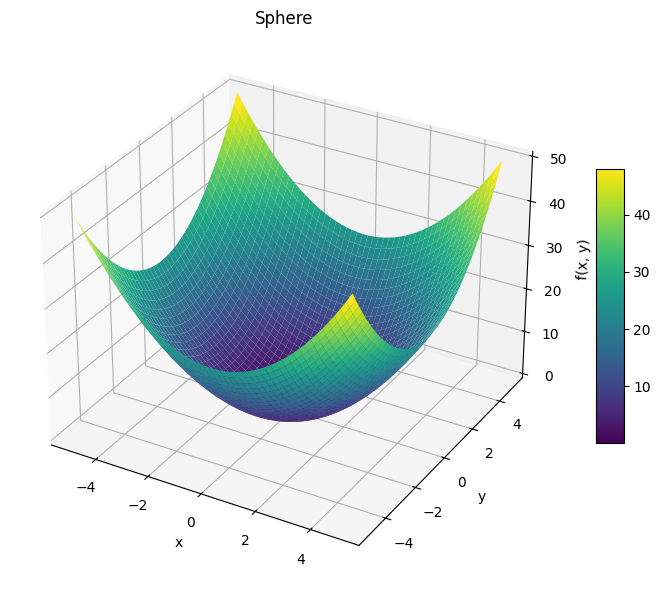

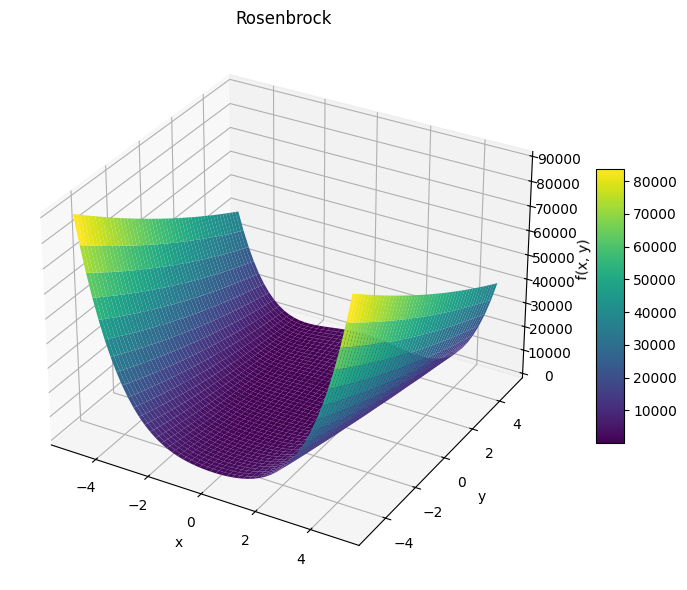

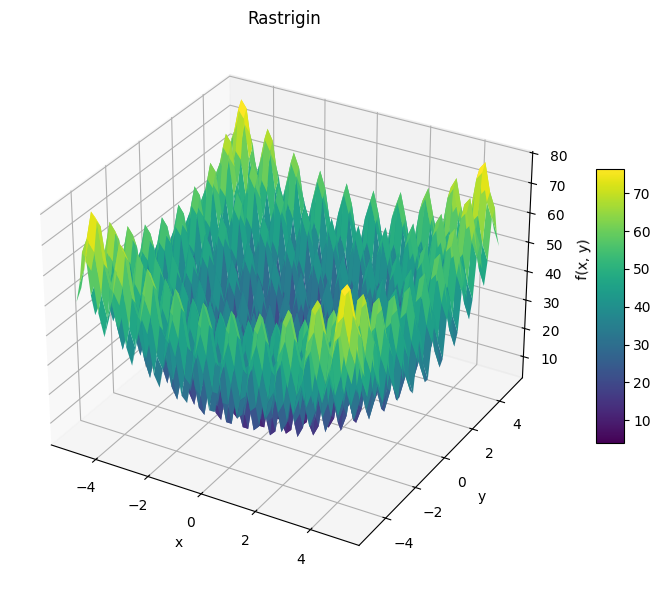

In [ ]:
problems = [Sphere(), Rosenbrock(), Rastrigin()]

for problem in problems:
    plot_3d_surface(problem)
    plot_contour_and_paths(problem, paths=[], title=problem.__class__.__name__)

<div class="alert alert-block alert-info">
<b>Comment:</b> The Sphere function seems to be the easiest to optimize because of its simple convex shape. At every point, the gradient points directly toward the minimum, which is also the global minimum. 

The Rastrigin function is likely the most difficult to optimize because it is highly irregular and contains many local minima. This can make optimization more challenging, especially for methods with momentum.
</div>

# Momentum

In [5]:
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
):
    x = initial_solution.copy().astype(float)
    velocity = np.zeros_like(x)

    path = [x.copy()]
    values = [problem(x)]
    velocity_norms = [np.linalg.norm(velocity)]

    for _ in range(number_of_epochs):
        grad = problem.grad(x)
        velocity = beta * velocity + alpha * grad
        x -= velocity

        path.append(x.copy())
        values.append(problem(x))
        velocity_norms.append(np.linalg.norm(velocity))

    return x, np.array(path), np.array(values), np.array(velocity_norms)

Experiments with Momentum

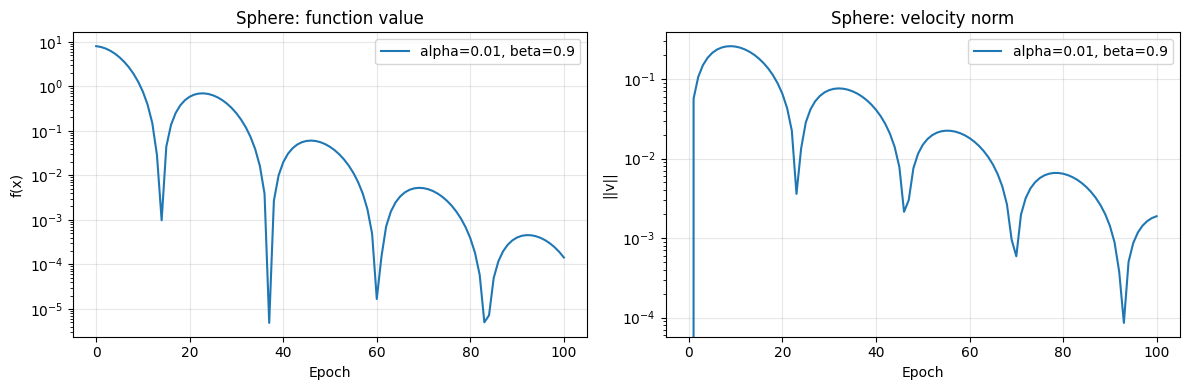

/tmp/ipykernel_25366/2562006258.py:24: RuntimeWarning: overflow encountered in square
  return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
/tmp/ipykernel_25366/2562006258.py:29: RuntimeWarning: overflow encountered in scalar multiply
  grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
/tmp/ipykernel_25366/1877190781.py:17: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + alpha * grad


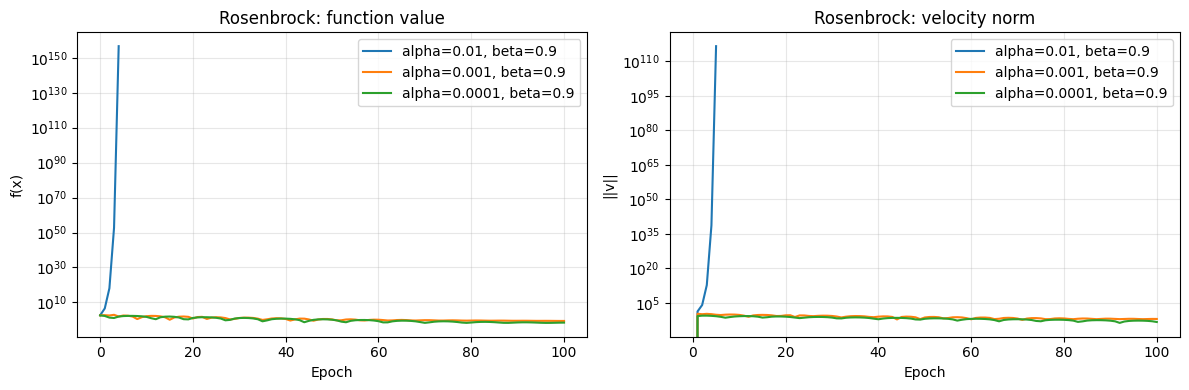

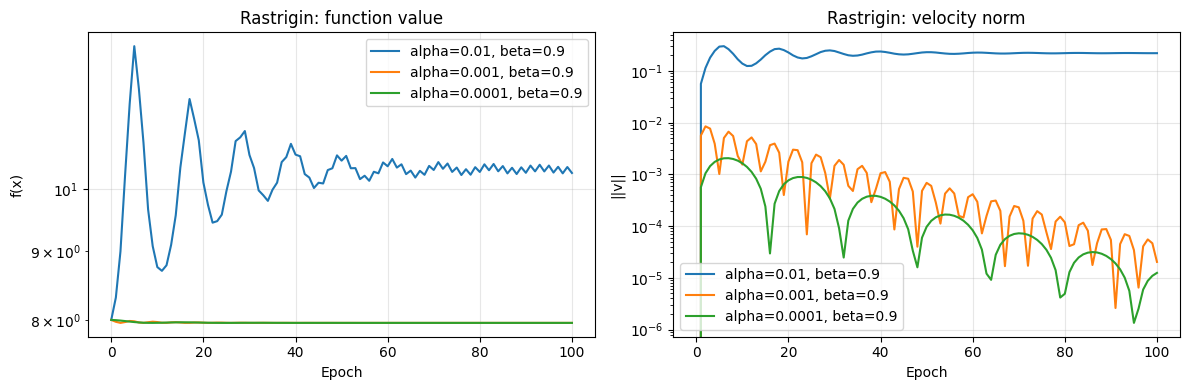

In [6]:
def plot_momentum_metrics(
    problem: Problem,
    alphas: list[float],
    beta: float = 0.9,
    number_of_epochs: int = 100,
):
    initial_solution = np.array([2.0, 2.0])

    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = np.arange(0, number_of_epochs + 1)

    for alpha in alphas:
        _, _, values, velocity_norms = momentum(
            problem=problem,
            initial_solution=initial_solution,
            alpha=alpha,
            beta=beta,
            number_of_epochs=number_of_epochs,
        )

        axes[0].plot(epochs, values, label=f"alpha={alpha}, beta={beta}")
        axes[1].plot(epochs, velocity_norms, label=f"alpha={alpha}, beta={beta}")

    axes[0].set_title(f"{problem.__class__.__name__}: function value")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("f(x)")
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title(f"{problem.__class__.__name__}: velocity norm")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(r"||v||")
    axes[1].set_yscale("log")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_momentum_metrics(Sphere(), alphas=[0.01], beta=0.9, number_of_epochs=100)
plot_momentum_metrics(Rosenbrock(), alphas=[0.01, 0.001, 0.0001], beta=0.9, number_of_epochs=100)
plot_momentum_metrics(Rastrigin(), alphas=[0.01, 0.001, 0.0001], beta=0.9, number_of_epochs=100)

<div class="alert alert-block alert-info">
<b>Comment:</b> At the beginning, Momentum usually speeds up because it accumulates previous updates. Depending on the hyperparameters, however, it can become unstable. For Sphere and Rastrigin, the method usually slows down near the minimum, while for Rosenbrock it is much more sensitive to the choice of parameters and may cause the velocity to grow too quickly.
</div>

Momentum Hyperparameters

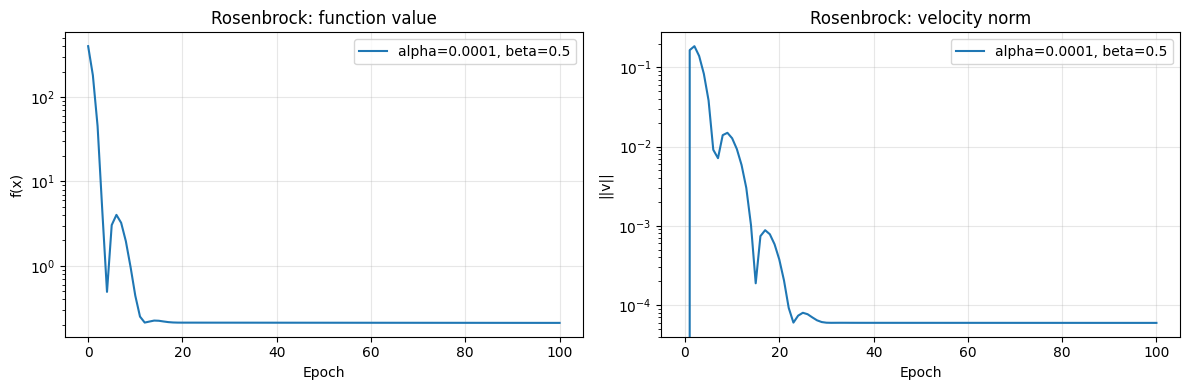

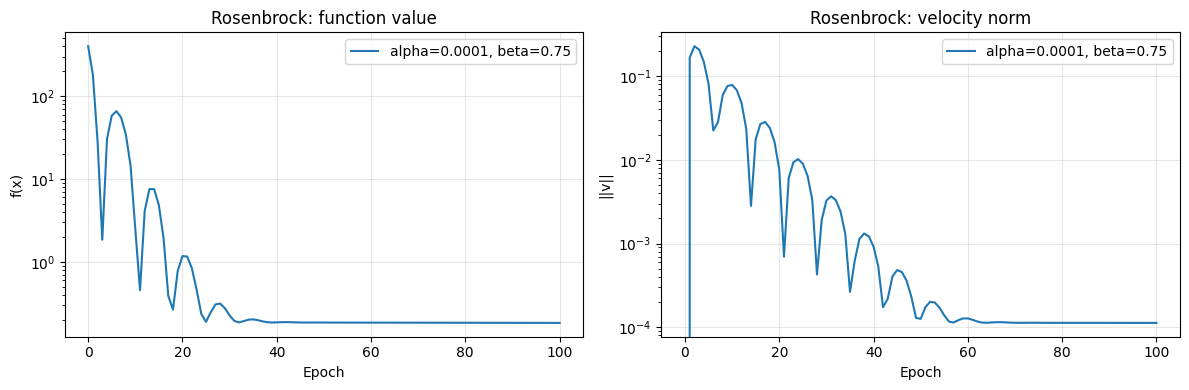

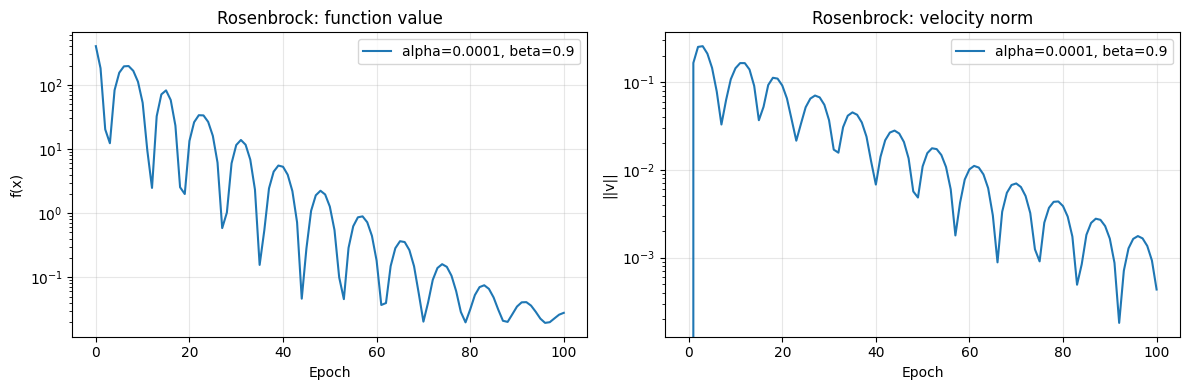

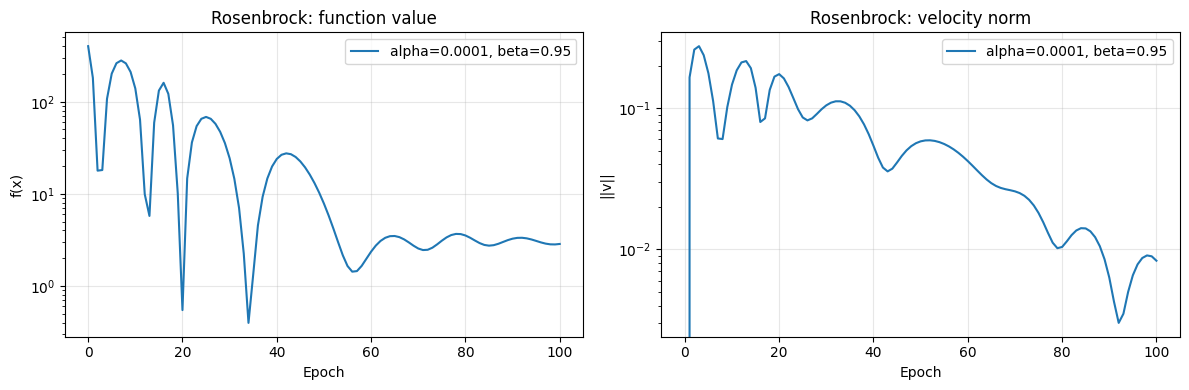

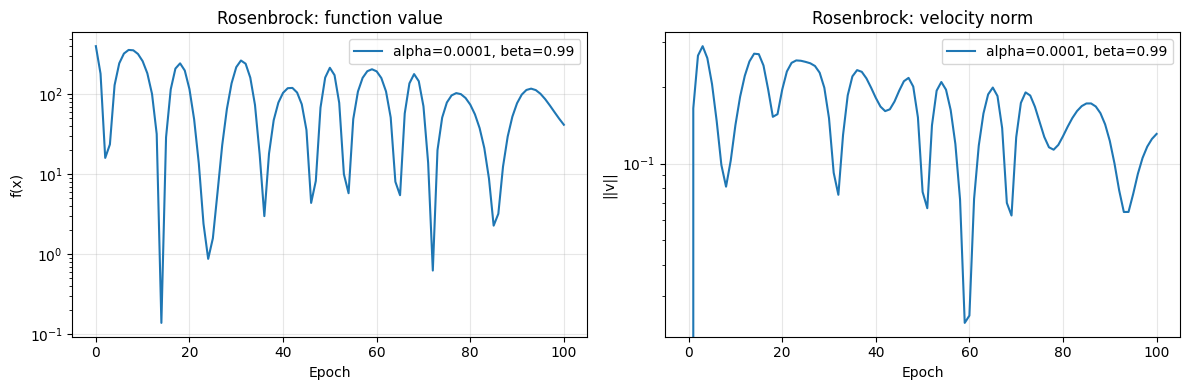

In [7]:
for beta in [0.5, 0.75, 0.9, 0.95, 0.99]:
    plot_momentum_metrics(Rosenbrock(), alphas=[1e-4], beta=beta, number_of_epochs=100)

<div class="alert alert-block alert-info">
<b>Comment:</b> The larger the value of beta, the harder it is to converge to the minimum. This happens because a high beta gives more weight to previous updates, making the method less responsive to local changes in the gradient.
</div>

## Adam

In [8]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8,
):
    x = initial_solution.copy().astype(float)
    m_t = np.zeros_like(x)
    v_t = np.zeros_like(x)

    path = [x.copy()]
    values = [problem(x)]

    for t in range(1, number_of_epochs + 1):
        grad = problem.grad(x)

        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        x -= alpha * m_hat / (np.sqrt(v_hat) + epsilon)

        path.append(x.copy())
        values.append(problem(x))

    return x, np.array(path), np.array(values)

# Comparison Adam and Momentum

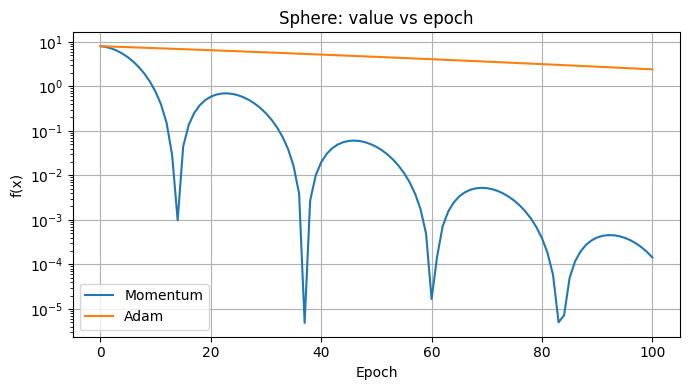

/tmp/ipykernel_25366/2562006258.py:24: RuntimeWarning: overflow encountered in square
  return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
/tmp/ipykernel_25366/2562006258.py:29: RuntimeWarning: overflow encountered in scalar multiply
  grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
/tmp/ipykernel_25366/1877190781.py:17: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + alpha * grad


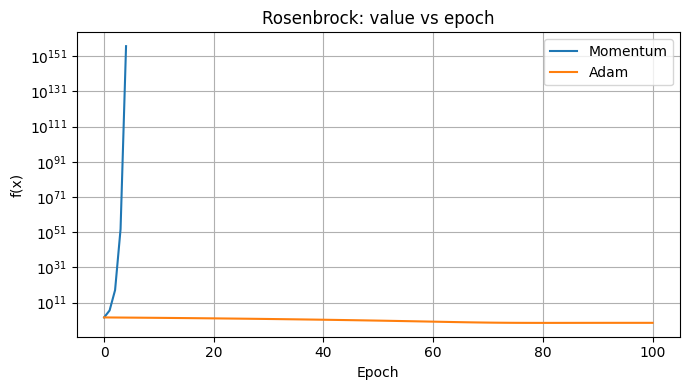

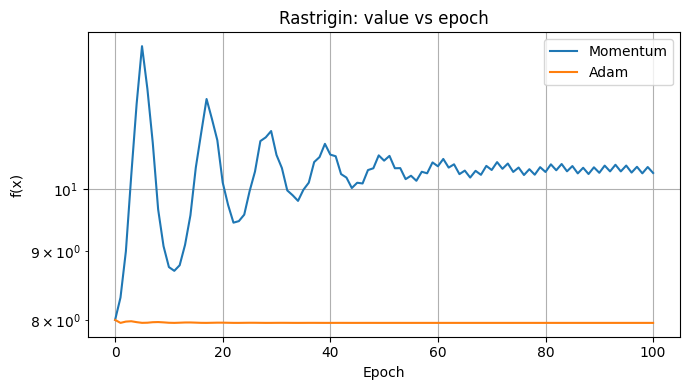

In [9]:
def compare_optimizers(problem: Problem, number_of_epochs: int):
    initial_solution = np.array([2.0, 2.0])

    _, momentum_path, momentum_values, _ = momentum(
        problem=problem,
        initial_solution=initial_solution,
        alpha=0.01,
        beta=0.9,
        number_of_epochs=number_of_epochs,
    )

    _, adam_path, adam_values = adam(
        problem=problem,
        initial_solution=initial_solution,
        alpha=0.01,
        beta1=0.9,
        beta2=0.999,
        number_of_epochs=number_of_epochs,
        epsilon=1e-8,
    )

    plot_contour_and_paths(
        problem,
        paths=[momentum_path, adam_path],
        title=f"{problem.__class__.__name__}: Momentum (Run 1) vs Adam (Run 2)",
    )

    epochs = np.arange(0, number_of_epochs + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, momentum_values, label="Momentum")
    plt.plot(epochs, adam_values, label="Adam")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("f(x)")
    plt.title(f"{problem.__class__.__name__}: value vs epoch")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

for problem in problems:
    compare_optimizers(problem, number_of_epochs=100)